In [1]:
# Try it out
# Titanic Dataset
# Task to the predict - what sorts of people were more likely to survive?

import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd

file_path = "./Titanic-Dataset.csv"

titanic_full: pd.DataFrame = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "yasserh/titanic-dataset",
  file_path,
)

print(titanic_full.info())
# Pclass - класс билета
# SibSp — кол-во братьев/сестёр/супругов на борту
# Parch — кол-во родителей/детей на борту
# Fare — цена билета
# Cabin — каюта
# Embarked — порт посадки

# Age Cabin Embarked есть пропуски has some missing

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [49]:
titanic_full.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [23]:
print(titanic_full["Name"].value_counts()[:3])
print(titanic_full["Sex"].value_counts())

Name
Dooley, Mr. Patrick                                    1
Braund, Mr. Owen Harris                                1
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    1
Name: count, dtype: int64
Sex
male      577
female    314
Name: count, dtype: int64


In [24]:
print(titanic_full["Ticket"].value_counts())

Ticket
1601         7
CA. 2343     7
347082       7
3101295      6
CA 2144      6
            ..
A/5 21172    1
349219       1
234818       1
345364       1
A/5 2466     1
Name: count, Length: 681, dtype: int64


In [25]:
print(titanic_full["Cabin"].value_counts())

Cabin
B96 B98        4
G6             4
C23 C25 C27    4
F2             3
C22 C26        3
              ..
C106           1
A19            1
D7             1
C118           1
E50            1
Name: count, Length: 147, dtype: int64


In [26]:
print(titanic_full["Embarked"].value_counts())

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


In [35]:
# Средняя цена по классу
print(titanic_full.groupby("Pclass")["Fare"].mean())

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64


In [ ]:
# Посадка порта и смертность
print(titanic_full.groupby("Embarked")["Survived"].mean())

# confounding variable — Embarked коррелирует с Pclass:
# в Шербуре (C) садилось больше богатых пассажиров (Pclass ~1.9)
# в Квинстауне (Q) — беднее (Pclass ~2.9)
# Поэтому Embarked всё же оставляем как feature — он несёт информацию
titanic_full.groupby("Embarked")["Pclass"].mean()

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


Embarked
C    1.886905
Q    2.909091
S    2.350932
Name: Pclass, dtype: float64

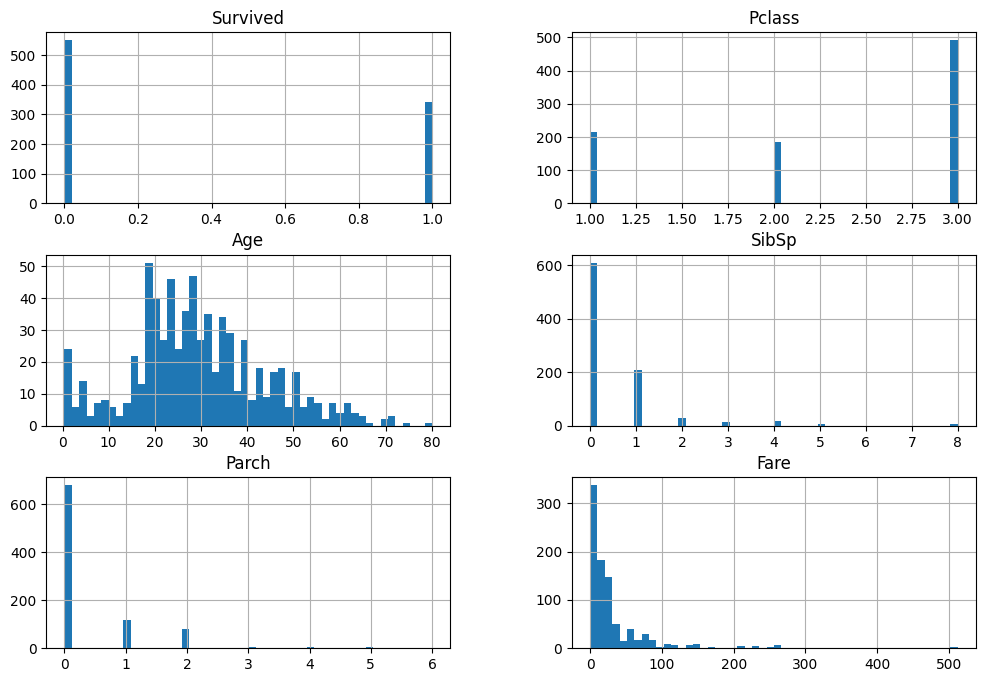

In [36]:
import matplotlib.pyplot as plt

# Original titanic_full don't be changed
titanic_full.drop(columns=["PassengerId"]).hist(bins=50, figsize=(12,8))
plt.show()

In [ ]:
# Для справки
# Stratified split by Pclass — сохраняем пропорции классов билетов (1/2/3)
# в train и test такими же как в оригинальном датасете (~55% / ~24% / ~21%).
# Без этого случайный split мог бы перекосить соотношение классов
# и модель обучалась бы на нечестных данных.

from sklearn.model_selection import StratifiedShuffleSplit
splitter = StratifiedShuffleSplit(n_splits=3, test_size=0.2, random_state=42)
strat_splits = []

for train_index, test_index in splitter.split(titanic_full, titanic_full["Pclass"]):
    strat_train_set_n = titanic_full.iloc[train_index]
    strat_test_set_n = titanic_full.iloc[test_index]
    strat_splits.append([strat_train_set_n, strat_test_set_n])

# Берём первый split из трёх
strat_train_set, strat_test_set = strat_splits[0]

original
 Pclass
3    0.551066
1    0.242424
2    0.206510
Name: count, dtype: float64
Pclass
3    0.553073
1    0.240223
2    0.206704
Name: count, dtype: float64
Pclass
3    0.550562
1    0.242978
2    0.206461
Name: count, dtype: float64


In [2]:
# Use a scikit-learn for create train set instead creating self shuffle and split
from sklearn.model_selection import train_test_split

# stratify=titanic_full["Pclass"] — говорим train_test_split по какой колонке
# сохранять пропорции. Автоматический аналог StratifiedShuffleSplit выше.
train_set, test_set = train_test_split(
    titanic_full, test_size=0.2, stratify=titanic_full["Pclass"], random_state=42
)

# Revert to a clean training set
# X (признаки)
titanic = train_set.drop("Survived", axis=1)
# y (целевая переменная)
titanic_survived_labels = train_set["Survived"].copy()
print("Train first - ", titanic.iloc[0], "\n")
print("Test first - ", test_set.iloc[0], "\n")

# X_test
test = test_set.drop("Survived", axis=1)

# y_test (понадобится для оценки модели)
test_survived_labels = test_set["Survived"].copy()

Train first -  PassengerId                                                  821
Pclass                                                         1
Name           Hays, Mrs. Charles Melville (Clara Jennings Gr...
Sex                                                       female
Age                                                         52.0
SibSp                                                          1
Parch                                                          1
Ticket                                                     12749
Fare                                                        93.5
Cabin                                                        B69
Embarked                                                       S
Name: 820, dtype: object 

Test first -  PassengerId                                               133
Survived                                                    0
Pclass                                                      3
Name           Robins, Mrs. Alexander A (Gr

<Axes: xlabel='Pclass,Sex'>

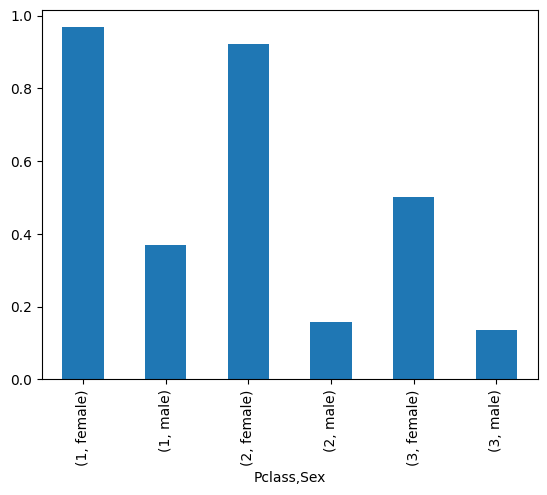

In [ ]:
# Exploratory Data Analysis
# Visualize
import matplotlib.pyplot as plt

survMean = titanic_full.groupby(["Pclass", "Sex"])["Survived"].mean()

survMean.plot(kind="bar")

In [ ]:
from pandas.plotting import scatter_matrix
#Look for Correlations 
corr_matrix = titanic_full.corr(numeric_only=True)
corr_matrix["Survived"].sort_values(ascending=False) 
# Pclass=1 это богатые (высокий шанс выжить), 
# Pclass=3 это бедные (низкий шанс выжить). 
# То есть чем больше число Pclass — тем меньше шанс выжить.


Survived       1.000000
Fare           0.257307
Parch          0.081629
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.077221
Pclass        -0.338481
Name: Survived, dtype: float64

In [ ]:
# Для справки
# 2.4 has some missing
# Ручная чистка данных (лучше использовать sklearn)

print(titanic["Age"].count())
print(titanic["Cabin"].count())
print(titanic["Embarked"].count())

# inplace=true мутация значения сохранение
# Cabin всего лишь 204, мало информации и не так важна
titanic.drop("Cabin", axis=1, inplace=True)
# Наполнить пропуски возраста среднем значением
medianAge = titanic["Age"].median()
titanic["Age"] = titanic["Age"].fillna(medianAge)

# Порт посадки Категория, наполняем более частым значением
mostFreqEmbarked = titanic["Embarked"].value_counts().index[0]
titanic["Embarked"] = titanic["Embarked"].fillna(mostFreqEmbarked)

titanic.info()


574
161
710
<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 820 to 144
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Pclass       712 non-null    int64  
 2   Name         712 non-null    object 
 3   Sex          712 non-null    object 
 4   Age          712 non-null    float64
 5   SibSp        712 non-null    int64  
 6   Parch        712 non-null    int64  
 7   Ticket       712 non-null    object 
 8   Fare         712 non-null    float64
 9   Embarked     712 non-null    object 
dtypes: float64(2), int64(4), object(4)
memory usage: 61.2+ KB


In [3]:
# Очистка данных с использованием Sklearn

from sklearn.impute import SimpleImputer

# === TRAIN (обучающая выборка) ===

# Удаляем Cabin (слишком много пропусков)
# Также удаляем Name он не нужен
# PassengerId не нужен в обучении
# Ticket просто почти как уникальный id
titanic = titanic.drop(["Cabin", "Name", "PassengerId", "Ticket"], axis=1)

# Импьютеры:
# для числовых — медиана
age_imputer = SimpleImputer(strategy="median")

# для категориальных — самое частое значение
embarked_imputer = SimpleImputer(strategy="most_frequent")

# fit_transform:
# fit — считаем статистику (только на train)
# transform — заполняем пропуски
titanic["Age"] = age_imputer.fit_transform(titanic[["Age"]]).ravel()
titanic["Embarked"] = embarked_imputer.fit_transform(titanic[["Embarked"]]).ravel()

print("Train:")
print(titanic.info())

# === TEST (тестовая выборка) ===

# Берём test и делаем те же шаги
test = test.drop(["Cabin", "Name", "PassengerId", "Ticket"], axis=1)

# ВАЖНО: только transform (без fit!)
# используем те же параметры, что посчитали на train
test["Age"] = age_imputer.transform(test[["Age"]]).ravel()
test["Embarked"] = embarked_imputer.transform(test[["Embarked"]]).ravel()

print("\nTest:")
print(test.info())

Train:
<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 820 to 144
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    712 non-null    int64  
 1   Sex       712 non-null    object 
 2   Age       712 non-null    float64
 3   SibSp     712 non-null    int64  
 4   Parch     712 non-null    int64  
 5   Fare      712 non-null    float64
 6   Embarked  712 non-null    object 
dtypes: float64(2), int64(3), object(2)
memory usage: 44.5+ KB
None

Test:
<class 'pandas.core.frame.DataFrame'>
Index: 179 entries, 132 to 203
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    179 non-null    int64  
 1   Sex       179 non-null    object 
 2   Age       179 non-null    float64
 3   SibSp     179 non-null    int64  
 4   Parch     179 non-null    int64  
 5   Fare      179 non-null    float64
 6   Embarked  179 non-null    object 
dtypes: float6

In [8]:
# Format text data to numerical data (encoding)
# Не трогаем оригинал, лишь изучаем преобразование текста в числовые значения
# Это потом будем делать в пайплайне
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

titanic_sex_cat = titanic[["Sex"]]
ordinal_encoder = OrdinalEncoder()
titanic_sex_cat_encoded = ordinal_encoder.fit_transform(titanic_sex_cat)

print(titanic_sex_cat_encoded[:8])
print(titanic_sex_cat[:8])
print(ordinal_encoder.categories_)


[[0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]]
        Sex
820  female
439    male
821    male
403    male
343    male
514    male
40   female
101    male
[array(['female', 'male'], dtype=object)]


In [ ]:
# Feature scaling изучение MinMaxScaler и StandardScaler

import numpy as np


# В признаке Fare есть выбросы:
# большинство значений лежит примерно в диапазоне 0–300,
# но встречаются значения ~500.
# Такие выбросы могут искажать масштабирование и влиять на обучение модели.

# Min-max scaling (normalization)
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

titanic_num = titanic.select_dtypes(include=[np.number])

min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
titanic_num_min_max_scaled = min_max_scaler.fit_transform(titanic_num)

# Original fare - 93.5, 10.5, 8.6625
print("original data - \n", titanic_num[:3].to_numpy(), "\n")

# Fare после MinMaxScaler: -0.635, -0.959, -0.966
print("titanic_num_min_max_scaled\n", titanic_num_min_max_scaled[:3])

# Standardization (z-score scaling)
std_scaler = StandardScaler()
titanic_num_std_scaled = std_scaler.fit_transform(titanic_num)

# Fare после StandardScaler: 1.259, -0.447, -0.485
print("housing_num_std_scaled\n", titanic_num_std_scaled[:3])


# Если посмотреть на оригинальные значения 10.5 и 8.66:
# - при MinMaxScaler они оказываются очень близко друг к другу,
#   потому что масштаб "растянут" из-за выброса (максимального значения).
# - при StandardScaler значения также сжимаются,
#   но не ограничены фиксированным диапазоном [-1, 1],
#   поэтому распределение выглядит более "растянутым"
#   и различия визуально заметнее.


print(titanic_num["Fare"].max())
print(titanic_num["Fare"].idxmax())

# Найти строку с максимальным Fare (выброс)
max_idx = titanic_num["Fare"].idxmax()
print("\nОригинал:", titanic_num.loc[max_idx, "Fare"])

# Найти эту же строку в scaled данных
# idxmax возвращает индекс из оригинального DataFrame,
# поэтому переводим его в позицию
pos = titanic_num.index.get_loc(max_idx)

print("MinMax:", titanic_num_min_max_scaled[pos, -1])
print("Standard:", titanic_num_std_scaled[pos, -1])

# MinMaxScaler:
# - использует минимум и максимум признака
# - из-за выброса "растягивает" диапазон
# - в результате большинство значений сжимаются в узкий интервал

# StandardScaler:
# - центрирует данные (mean=0) и масштабирует по стандартному отклонению
# - тоже чувствителен к выбросам (они влияют на mean и std),
#   но не ограничивает диапазон значений
# - поэтому не сжимает данные так сильно, как MinMaxScaler

original data - 
 [[ 1.     52.      1.      1.     93.5   ]
 [ 2.     31.      0.      0.     10.5   ]
 [ 3.     27.      0.      0.      8.6625]] 

titanic_num_min_max_scaled
 [[-1.          0.2963056  -0.75       -0.66666667 -0.63500031]
 [ 0.         -0.23146519 -1.         -1.         -0.95901073]
 [ 1.         -0.33199296 -1.         -1.         -0.96618385]]
housing_num_std_scaled
 [[-1.56405658  1.76806358  0.44064412  0.75965314  1.259243  ]
 [-0.36791449  0.14731153 -0.49033099 -0.47804259 -0.44732737]
 [ 0.8282276  -0.16140314 -0.49033099 -0.47804259 -0.48510837]]
512.3292
258

Оригинал: 512.3292
MinMax: 1.0
Standard: 9.870827363959615


In [9]:
# Feature scaling — сравнение методов на реальных данных Titanic
# Проблема: распределение Fare сильно скошено (skewed):
# большинство значений ~10–100, но есть редкие выбросы ~500.
#
# Важно:
# Модель "смотрит" не на сами значения, а на расстояния / масштабы.
# Если масштаб искажён — модель начинает переоценивать выбросы.

from sklearn.preprocessing import FunctionTransformer, MinMaxScaler, StandardScaler

# Реальные значения Fare из датасета
fare_min = titanic_num["Fare"].min()
fare_mean = titanic_num["Fare"].mean()
fare_max = titanic_num["Fare"].max()

print(f"Оригинал  — min: {fare_min:.2f}, mean: {fare_mean:.2f}, max: {fare_max:.2f}")


# -------------------------
# MinMaxScaler
# -------------------------
# Идея: просто растянуть данные в диапазон [-1, 1]
# Формула: (x - min) / (max - min)
#
# ПРОБЛЕМА:
# если есть выброс (512), он становится max,
# и ВСЕ остальные значения масштабируются относительно него.
#
# В итоге:
# - значения 10–100 сжимаются в узкий диапазон около 0
# - различия между "обычными" значениями почти исчезают
#
# Для модели это значит:
# она хуже различает "нормальные" объекты между собой

mm = MinMaxScaler(feature_range=(-1, 1))
fare_mm = mm.fit_transform(titanic_num[["Fare"]])

print(f"MinMax    — min: {mm.transform([[fare_min]])[0][0]:.3f}, "
      f"mean: {mm.transform([[fare_mean]])[0][0]:.3f}, "
      f"max: {mm.transform([[fare_max]])[0][0]:.3f}")


# -------------------------
# StandardScaler
# -------------------------
# Идея: центрировать данные (mean=0) и масштабировать по std
# Формула: (x - mean) / std
#
# ВАЖНО:
# выброс влияет на mean и std → он НЕ игнорируется
#
# НО:
# - диапазон НЕ ограничен
# - данные не "сжимаются" в фиксированный интервал
#
# В итоге:
# - обычные значения сохраняют относительные различия лучше, чем в MinMax
# - выброс просто получает большое значение (например 9)
#
# Для модели:
# - расстояния между обычными объектами остаются значимыми
# - выброс не "сжимает" всё остальное

std = StandardScaler()
std.fit(titanic_num[["Fare"]])

print(f"Standard  — min: {std.transform([[fare_min]])[0][0]:.3f}, "
      f"mean: {std.transform([[fare_mean]])[0][0]:.3f}, "
      f"max: {std.transform([[fare_max]])[0][0]:.3f}")


# -------------------------
# Log transform
# -------------------------
# Идея: изменить САМУ форму распределения (не просто масштаб)
#
# лог "сжимает" большие значения сильнее, чем маленькие:
# 10 → 2.3
# 100 → 4.6
# 512 → 6.2
#
# В итоге:
# - уменьшается разница между выбросами и нормальными значениями
# - распределение становится более "симметричным"
#
# Для модели:
# - выбросы перестают доминировать
# - модель лучше обучается на "массе" данных

log_transformer = FunctionTransformer(np.log, inverse_func=np.exp)

print(f"Log       — min: {np.log(max(fare_min, 0.01)):.3f}, "
      f"mean: {np.log(fare_mean):.3f}, "
      f"max: {np.log(fare_max):.3f}")

Оригинал  — min: 0.00, mean: 32.26, max: 512.33
MinMax    — min: -1.000, mean: -0.874, max: 1.000
Standard  — min: -0.663, mean: 0.000, max: 9.871
Log       — min: -4.605, mean: 3.474, max: 6.239


/home/sieugene/Desktop/work/handson-ml3/venv/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/sieugene/Desktop/work/handson-ml3/venv/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/sieugene/Desktop/work/handson-ml3/venv/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/sieugene/Desktop/work/handson-ml3/venv/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/sieugene/Desktop/work/handson-ml3/venv/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScale

почему MinMax плохо, если диапазон нормальный [-1,1]?
- Потому что важен не диапазон, а распределение внутри него
MinMax:
10   → -0.95
50   → -0.85
100  → -0.70
512  → 1.00
Что происходит:
ВСЕ нормальные значения сжались в кусочек [-1, -0.7]
модель почти не видит разницы между ними

MinMaxScaler чувствителен к выбросам, потому что использует глобальные min/max, из-за чего плотная часть распределения сжимается.
StandardScaler тоже чувствителен, но не ограничивает диапазон, поэтому сохраняет относительные расстояния лучше.
Логарифм — это уже не scaling, а изменение распределения, что часто эффективнее при сильном skew.